![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Hands-On Session: Explainable AI for Random Forest Models

Building on the previously trained Random Forest classifier for **AML vs. non-AML** prediction, this notebook focuses on interpreting and analyzing the model’s decision-making process. Using RNA-seq gene expression data from [Warnat-Herresthal et al. (2020)](https://doi.org/10.1016/j.isci.2019.100780), we apply and compare multiple explainability methods to understand which genes drive the model’s predictions. The objectives of this notebook are to compute and compare model-agnostic and model-specific explanation methods, critically assess their differences, and reflect on the strengths and limitations of each approach in a high-dimensional, multi-study biomedical setting.

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your own machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. In order to start working on the notebook, click on the following button. This will open this page in the Colab environment and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-random-forest/Bio-7-HandsOn_AML_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive and you can navigate it through the lefthand panel in Colab, you might also have received an email that informs you about the access on your Google Drive.

In [ ]:
# Mount drive folder to dbe abale to download repo
# from google.colab import drive
# drive.mount('/content/drive')

# Switch to correct folder'
# %cd /content/drive/MyDrive

In [ ]:
# Don't run this cell if you already cloned the repo 
# %rm -r XAI-Tutorials
# !git clone --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git

In [ ]:
# Install al required dependencies and package versions
# %cd XAI-Tutorials
# !pip install -r requirements_xai-for-random-forest.txt
# %cd xai-for-random-forest

### Imports

Let's start with importing all required Python packages.

In [1]:
# Load the required packages

import os
import sys
import pickle

import numpy as np

import shap
from fgclustering import (
    forest_guided_clustering, 
    forest_guided_feature_importance, 
    plot_forest_guided_feature_importance, 
    plot_forest_guided_decision_paths,
    DistanceRandomForestProximity,
    ClusteringKMedoids,
)
from sklearn.metrics import get_scorer, balanced_accuracy_score
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt

sys.path.append('./')
import utils

Now, we fix the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [2]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)

## Load Processed Data and Trained Model

In this step, we load the processed RNA-seq dataset and the previously trained Random Forest model. The datasets consist of a total of **1,181 samples** with 508 AML, 74 Leukemia and 599 healthy/other samples drived from two cell types (Peripheral Blood Mononuclear Cells (PBMC) and Bone Marrow (BM)) and 23 studies. The dataset includes **log2-transformed, normalized gene expression values** for over **12,000 genes**. Our goal is to **predict the AML status** and find out the major differences between AML - non-AML samples.

The trained model will serve as the basis for applying and comparing different explainability (XAI) methods.

In [3]:
output_dir = "aml_case_study"

In [4]:
# load previously stored data
with open(os.path.join(output_dir, "data_train_test.pickle"), "rb") as handle:
    data_train, data_test, gene_features = pickle.load(handle)

X_train = data_train[gene_features].reset_index(drop=True)
y_train = data_train["Condition"].reset_index(drop=True)

X_test = data_test[gene_features].reset_index(drop=True)
y_test = data_test["Condition"].reset_index(drop=True)

print(f"Number of training samples {X_train.shape[0]} ({round(X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100)}%) with {sum(y_train=='0_Control')} control and {sum(y_train=='1_Cancer')} cancer samples.")
print(f"Number of testing samples {X_test.shape[0]} ({round(X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100)}%) with {sum(y_test=='0_Control')} control and {sum(y_test=='1_Cancer')} cancer samples.")

Number of training samples 783 (66%) with 538 control and 245 cancer samples.
Number of testing samples 398 (34%) with 135 control and 263 cancer samples.


In [5]:
# load previously trained model
with open(os.path.join(output_dir, "rf_model.pickle"), "rb") as handle:
    rf_model = pickle.load(handle)

rf_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [6]:
# check model performance
y_pred_train_val = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# is the model performing reasonably on the training data?
print(f'Model Performance on training data: {round(balanced_accuracy_score(y_train, y_pred_train_val)*100,2)} % macro accuracy.')

# is the model performing reasonably on the test data?
print(f'Model Performance on test data: {round(balanced_accuracy_score(y_test, y_pred_test)*100,2)} % macro accuracy.')

Model Performance on training data: 100.0 % macro accuracy.
Model Performance on test data: 97.19 % macro accuracy.


## Now, what are our possibilities to interpret a Random Forest model?

After training and evaluating our Random Forest model on the RNA-seq dataset, the next step is to understand *how* the model arrives at its predictions. Tree-based ensemble models are powerful but inherently complex, making their internal decision logic difficult to interpret directly.

In this notebook, we explore and compare different explainability (XAI) approaches that offer complementary perspectives on model behavior. These methods allow us to analyze global feature importance, local prediction mechanisms, and subgroup-specific decision structures. For this analysis, we apply the XAI methods to the **training dataset** in order to investigate what the model has learned during training.

However, it is important to keep in mind that interpretations derived from the training data may reflect training-specific patterns. Therefore, it is always recommended to verify the consistency and stability of explanations on an independent test set to ensure that the identified patterns generalize beyond the training data.

By contrasting their assumptions, strengths, and limitations, we aim to develop a deeper understanding of how interpretability methods behave in high-dimensional, correlated transcriptomic data.

First, we examine the distribution of gene–gene correlations to assess feature dependence in the dataset, as several explainability methods rely on (explicit or implicit) assumptions of feature independence.

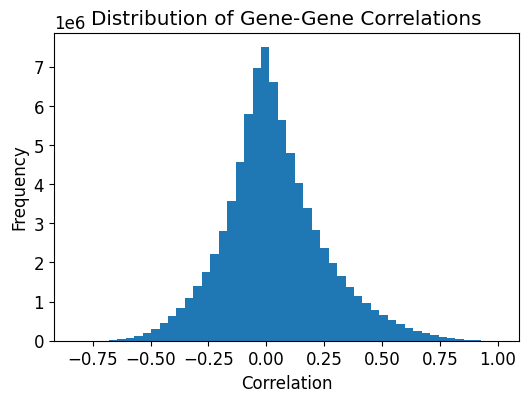

In [7]:
utils.plot_correlation_distribution(data_train)

The distribution of gene–gene correlations shows that many genes exhibit moderate to strong correlations, indicating substantial redundancy in the RNA-seq feature space. This has important implications for explainability methods.

In highly correlated settings, feature importance measures that rely on perturbing individual variables may underestimate the relevance of features, as correlated genes can compensate for each other. Additive attribution methods such as SHAP may distribute importance across correlated predictors, while subgroup-based approaches like Forest-Guided Clustering can capture collective patterns without relying on feature independence assumptions.

Thus, understanding the correlation structure is essential for interpreting and comparing XAI results in high-dimensional transcriptomic data.

In [8]:
# we only want to plot the top features for sake of visualisation
top_n = 30

### Interpretation with Feature Importance Measures

#### Permutation Feature Importance

Recall, the Permutation Feature Importance is defined to be the decrease in a model score when a single feature value is randomly permuted. This procedure breaks the relationship between the feature and the target. Thus the drop in the model score is indicative of how much the model depends on the feature. Lets now apply it to our dataset:

<font color='green'>

#### Task 1: Apply Permutation Feature Importance to identify which genes drive the model’s predictions.

*Note: Computing permutation feature importance can be computationally expensive, particularly in high-dimensional datasets such as RNA-seq data. We therefore recommend running this analysis in a separate notebook to avoid slowing down the remainig tasks. To speed up computations, you can set the n_repeats to 5 or lower.*

To compute permutation feature importances, we first need to define a scoring metric. In this case, we use "accuracy" to evaluate performance. The permutation procedure is then applied feature by feature, which requires repeatedly re-evaluating the model. Because each feature is permuted separately, the process can be computationally intensive, especially in high-dimensional settings.

/opt/anaconda3/envs/xai/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


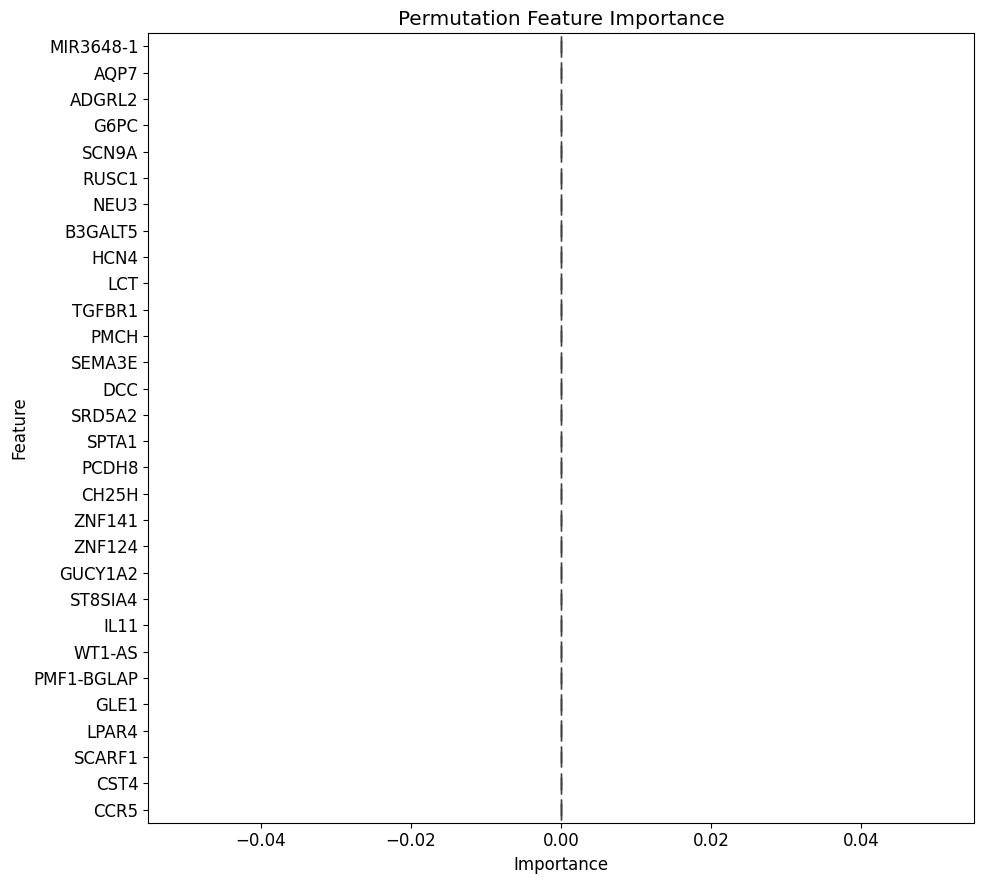

In [9]:
scorer = get_scorer("accuracy")
result = permutation_importance(rf_model, X_train, y_train, n_repeats=5, scoring=scorer, random_state=seed, n_jobs=8)
utils.plot_permutation_feature_importance(result=result, data=X_train, title="Permutation Feature Importance", figsize=(10,9), top_n=top_n)

#### Random Forest Feature Importance

An alternative to Permutation Feature Importance is the Random Forest specific feature importance method based on the mean decrease in impurity. The mean decrease in impurity is defined as the total decrease in node impurity averaged over all trees of the ensemble. This Feature Importances is directly provided by the fitted attribute `feature_importances_` .

Lets plot the feature importance based on mean decrease in impurity:

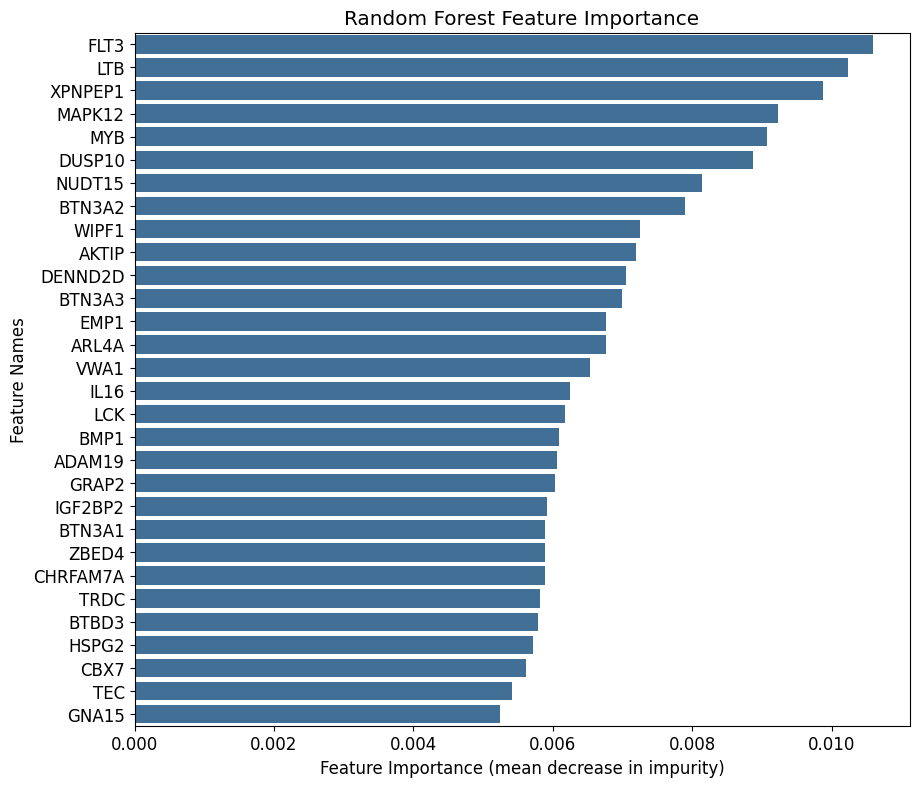

In [10]:
utils.plot_impurity_feature_importance(rf_model.feature_importances_, names=X_train.columns, title="Random Forest Feature Importance", top_n=top_n, figsize=(10,9))

### Interpretation with SHAP

Recall, with SHAP we get contrastive explanations that compare the prediction with the average prediction. The global interpretations are consistent with the local explanations, since the Shapley values are the “atomic unit” of the global interpretations.

<font color='green'>

#### Task 2: Use SHAP to identify the genes with the highest contributions and analyze one AML and one non-AML patient using the SHAP methods introduced earlier.

*Note: To speed up computations, you can initialize the `TreeExplainer` with a smaller background dataset. This may result in slight differences in the expected value (baseline), but in practice these deviations are typically small and do not substantially affect the overall interpretation.*

To apply SHAP to our model, we must select an appropriate explainer. Since we are interpreting a tree-based model (Random Forest), we use the `TreeExplainer()`, which is specifically optimized for tree ensembles. Because this is a classification task, we set the model output to "probability", so that SHAP values explain contributions in terms of predicted class probabilities rather than raw log-odds.

In [11]:
# run SHAP
explainer = shap.TreeExplainer(model=rf_model, data=shap.maskers.Independent(X_train, max_samples=300), model_output="probability")
shap_values = explainer(X_train)

100%|===================| 1562/1566 [06:03<00:00]        

Remember that the SHAP values explain why a prediction for a single observation is different from the average prediction for all the observations in the data set. For our AML classifier, the shap explainer produces two expected values, corresponding to the average predicted probability for each class.

In [12]:
# average prediction for the dataset
ev = explainer.expected_value
pm = np.mean(rf_model.predict_proba(X_train), axis=0)

print(f'Models average prediction for our data set is for class 0: {round(pm[0],3)}, for class 1: {round(pm[1],3)}')
print(f'Expected value for our data set is for class 0: {round(ev[0],3)}, for class 1: {round(ev[1],3)}')

Models average prediction for our data set is for class 0: 0.687, for class 1: 0.313
Expected value for our data set is for class 0: 0.689, for class 1: 0.311


To get a general overview on the features with the highest contributions, we can plot the average absolute SHAP values for each class.

The new SHAP bar plot implementation automatically aggregates all remaining features into a single category (“Sum of other features”). In high-dimensional settings such as RNA-seq data (12,000+ genes), this aggregated bar can dominate the visualization and make it difficult to meaningfully compare the top-ranked features. Since individual SHAP values are relatively small and distributed across many correlated predictors, the aggregated contribution of thousands of remaining features appears disproportionately large. As a result, the new bar plot can become less informative in very high-dimensional feature spaces.

For this reason, we use the legacy SHAP bar plot function, which allows us to display only the top features without aggregating the remainder. This provides a clearer comparison of the most influential genes and improves interpretability in large-scale transcriptomic datasets.

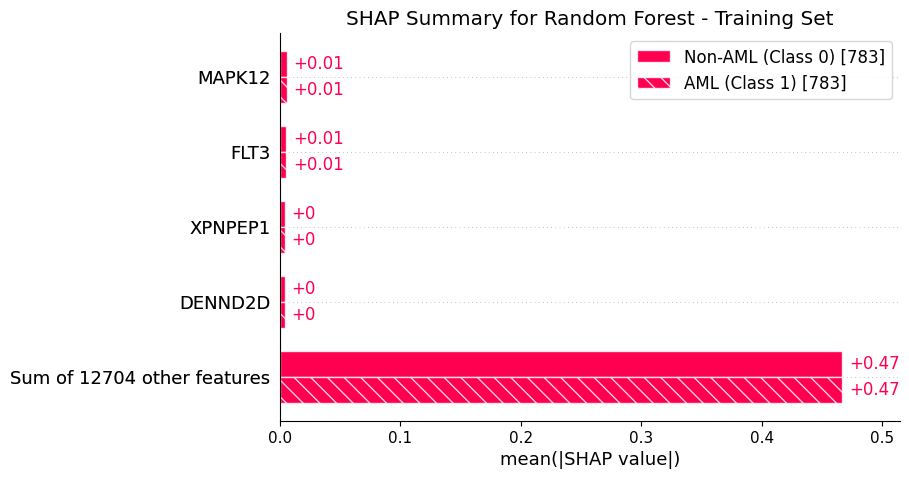

In [13]:
class_explanations = {
    "Non-AML (Class 0)": shap_values[:, :, 0],
    "AML (Class 1)": shap_values[:, :, 1],
}

shap.plots.bar(class_explanations, max_display=5, show=False)
plt.title("SHAP Summary for Random Forest - Training Set")
plt.show() 

/var/folders/8g/7wdchs993770j0nbzbt5p0_r0000gn/T/ipykernel_82914/1504304880.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(explanation_old.values, explanation_old.data, plot_type='bar', max_display=top_n)


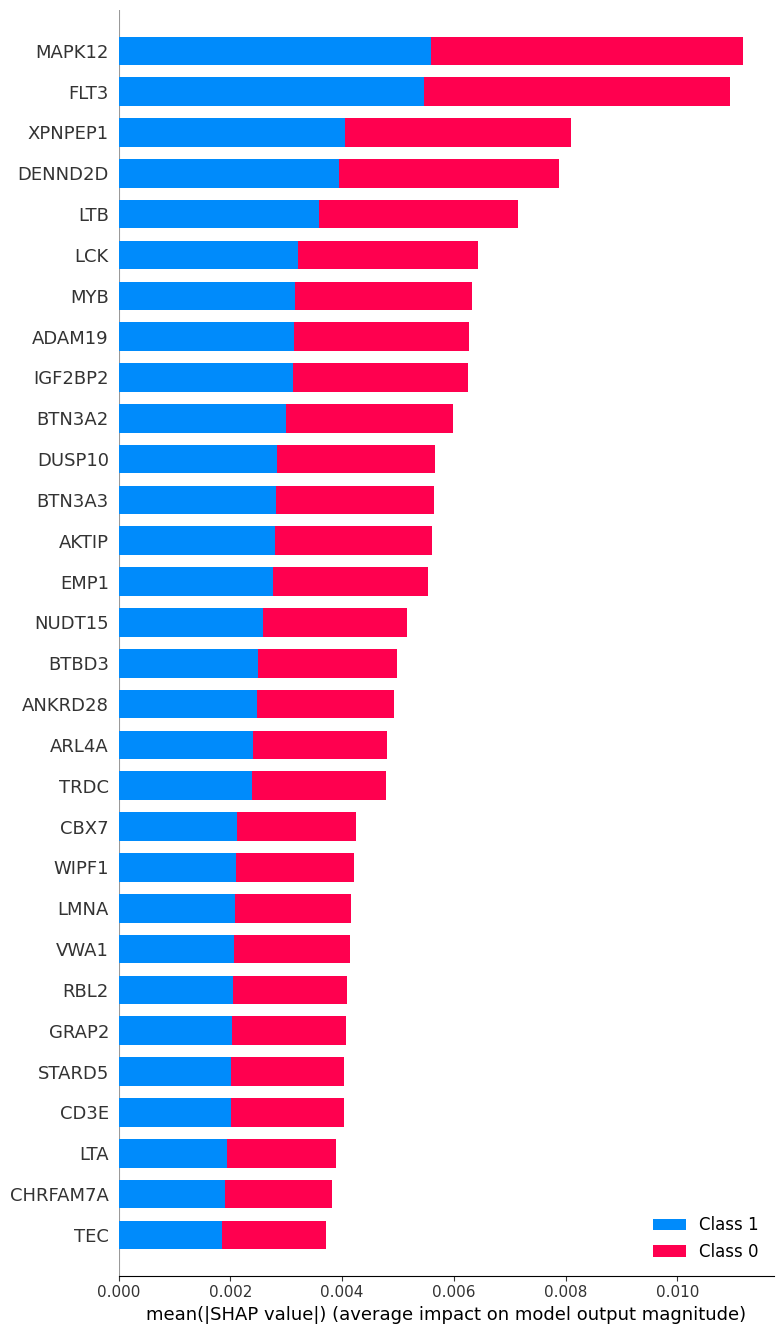

In [14]:
# using the legacy bar plot for better visualizations
explanation_old = shap.Explanation(
        values=list(np.transpose(shap_values.values,(2,0,1))),
        base_values=shap_values.base_values,
        data=X_train.round(4) ,
        feature_names=X_train.columns.tolist(),
    )

shap.summary_plot(explanation_old.values, explanation_old.data, plot_type='bar', max_display=top_n)

For a more detailed view of feature contributions, we can use SHAP beeswarm or violin plots. In classification settings, these plots must be generated separately for each class, as SHAP values are class-specific.

Since our primary interest lies in understanding what drives AML classification, we focus on the beeswarm plot for class 1 (AML). In a binary classification setting, SHAP values for the two classes are symmetric with opposite signs when explaining probabilities, meaning that the interpretation for the non-AML class does not provide fundamentally new information. Therefore, visualizing the AML class alone is sufficient for our analysis.

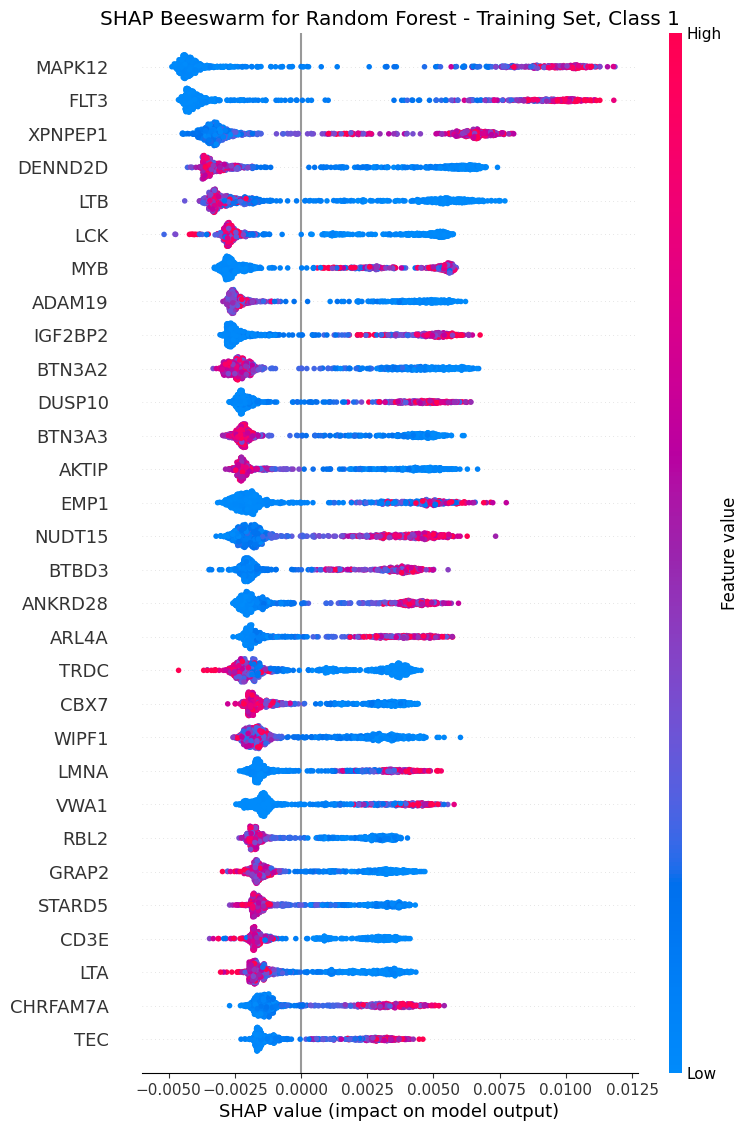

In [15]:
# summary plot for class 1 = AML
target_class = 1
shap.plots.beeswarm(shap_values[:, :, target_class], max_display=top_n, group_remaining_features=False, show=False)
plt.title("SHAP Beeswarm for Random Forest - Training Set, Class 1")
plt.show()

It is also important to note that the SHAP values appear numerically small. This is expected, as we are explaining predicted probabilities, which are bounded between 0 and 1. Since the prediction probability range is limited, individual feature contributions must also lie within this scale. In high-dimensional models, the prediction is typically influenced by many features simultaneously, resulting in relatively small SHAP values per feature that collectively sum to the final probability shift from the baseline.

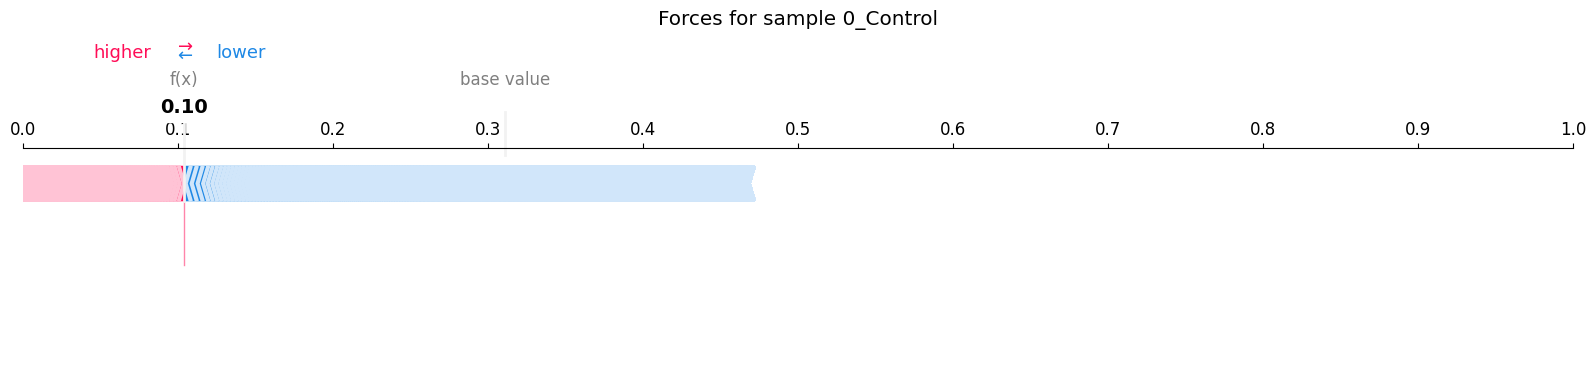

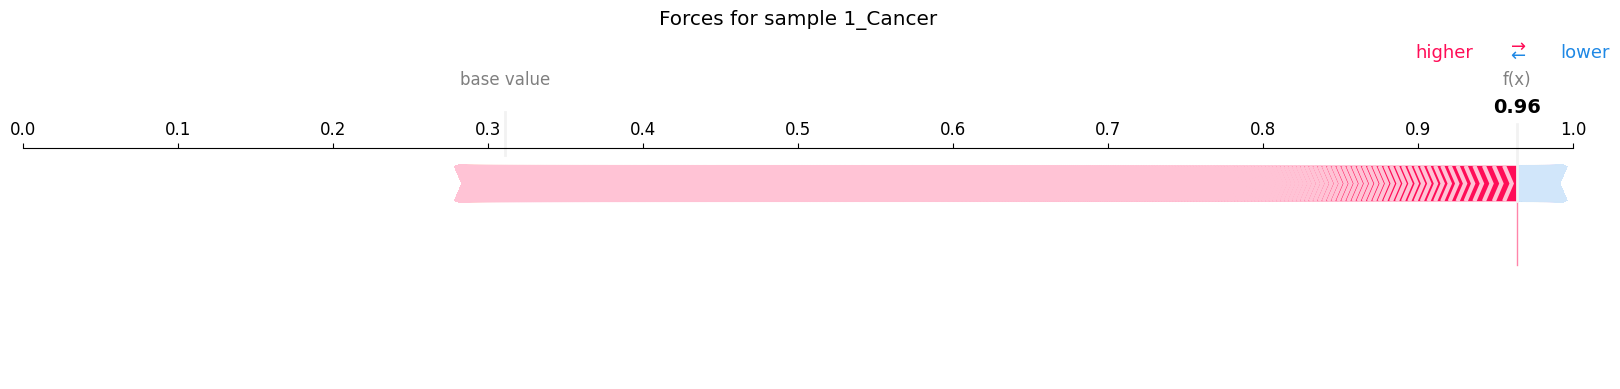

In [16]:
target_class = 1
sample_control = 9
sample_aml = 20

fig = shap.plots.force(shap_values[sample_control, :, target_class], matplotlib=True, show=False) 
ax = plt.gca() 
ax.set_xlim(0, 1) # enforce constant range 
ax.set_title(f"Forces for sample {y_train.iloc[sample_control]}", y=1.5) 
plt.show()

fig = shap.plots.force(shap_values[sample_aml, :, target_class], matplotlib=True, show=False) 
ax = plt.gca() 
ax.set_xlim(0, 1) # enforce constant range 
ax.set_title(f"Forces for sample {y_train.iloc[sample_aml]}", y=1.5) 
plt.show()

In such high-dimensional settings, force plots become difficult to interpret because thousands of small feature contributions collectively determine the prediction. While it is tempting to display only the top-ranked features, doing so omits remaining contributions and therefore no longer faithfully reconstructs the predicted value.

### Interpretation with Forest-Guided Clustering

Recall, FGC does not assume independence of model features, because it computes the feature importance based on subgroups of instances that follow similar decision rules within the Random Forest model.

<font color='green'>

#### Task 3: Apply Forest-Guided Clustering (FGC) to identify subgroups of samples with similar decision paths in the Random Forest model and analyze how cluster-specific feature importance and metadata distributions provide additional insight beyond global feature attribution methods.

We begin by determining the optimal number of clusters (k). FGC internally evaluates multiple values of k in the range 2–10 using stability-based clustering metrics (e.g., Jaccard Index) and selects the most stable solution. 

In [17]:
# define number of clusters and obtain clustered data
fgc = forest_guided_clustering(
    k=(2,10),
    estimator=rf_model, 
    X=X_train, 
    y=y_train, 
    clustering_distance_metric=DistanceRandomForestProximity(), 
    clustering_strategy=ClusteringKMedoids(method="fasterpam", max_iter=100),
    JI_discart_value=0.9,
)

Using a sample size of 80.00% of the input data for Jaccard Index computation.
Using range k = (2, 10) to optimize k.


Optimizing k: 100%|██████████| 9/9 [03:05<00:00, 20.58s/it]


Optimal number of clusters k = 8

Clustering Evaluation Summary:
 k    Score  Stable  Mean_JI                                                                                          Cluster_JI
 2 0.007326    True    1.000                                                                                    {1: 1.0, 2: 1.0}
 3 0.004884    True    0.992                                                                        {1: 1.0, 2: 0.976, 3: 0.999}
 4 0.002757    True    0.938                                                             {1: 0.999, 2: 0.984, 3: 0.959, 4: 0.81}
 5 0.002206    True    0.906                                                  {1: 0.998, 2: 0.979, 3: 0.882, 4: 0.724, 5: 0.947}
 6 0.000617    True    0.966                                          {1: 1.0, 2: 0.932, 3: 0.996, 4: 0.993, 5: 0.992, 6: 0.881}
 7 0.000529    True    0.950                                {1: 1.0, 2: 0.989, 3: 0.994, 4: 0.924, 5: 0.989, 6: 0.879, 7: 0.872}
 8 0.000463    True    0.931   

Here, the best solution is found at k = 8 clusters, indicating the model recognizes 8 meaningful subgroups in the decision space. 

#### Basic Analysis with FGC

After identifying the clusters derived from the Random Forest decision paths, we compute feature importance both at the cluster level (local importance) and across the full dataset (global importance). Importance is quantified using the Wasserstein distance, which measures differences between feature distributions across clusters.

These cluster-specific and global importance scores highlight which genes are most influential in separating distinct decision regions of the model, revealing how feature relevance varies across subpopulations rather than assuming a single global importance structure.

In [18]:
# calculate feature importance on the full gene set
feature_importance = forest_guided_feature_importance(
    X=X_train, 
    y=y_train, 
    y_pred=rf_model.predict(X_train),
    cluster_labels=fgc.cluster_labels[fgc.best_k],
    feature_importance_distance_metric="wasserstein",
)

 51%|█████     | 6463/12708 [00:08<00:08, 762.97it/s]

 - Skipping feature with zero variance.


 63%|██████▎   | 8001/12708 [00:10<00:06, 777.16it/s]

 - Skipping feature with zero variance.


 67%|██████▋   | 8471/12708 [00:11<00:05, 775.74it/s]

 - Skipping feature with zero variance.


 69%|██████▉   | 8794/12708 [00:11<00:04, 801.71it/s]

 - Skipping feature with zero variance.


 78%|███████▊  | 9965/12708 [00:13<00:03, 759.09it/s]

 - Skipping feature with zero variance.


 92%|█████████▏| 11746/12708 [00:15<00:01, 777.61it/s]

 - Skipping feature with zero variance.


 99%|█████████▊| 12528/12708 [00:16<00:00, 759.84it/s]

 - Skipping feature with zero variance.


100%|██████████| 12708/12708 [00:16<00:00, 759.14it/s]


The feature importance plot indicates that most clusters are characterized by distinct gene expression signatures among their top-ranking features. This suggests that different subgroups of samples are driven by partially unique gene patterns. Notably, three genes (BTN3A3, CD48, and GVINP1) appear among the top features in both AML-enriched and control-associated clusters, indicating that certain genes may contribute to multiple decision regions and potentially play context-dependent roles in the model’s classification.

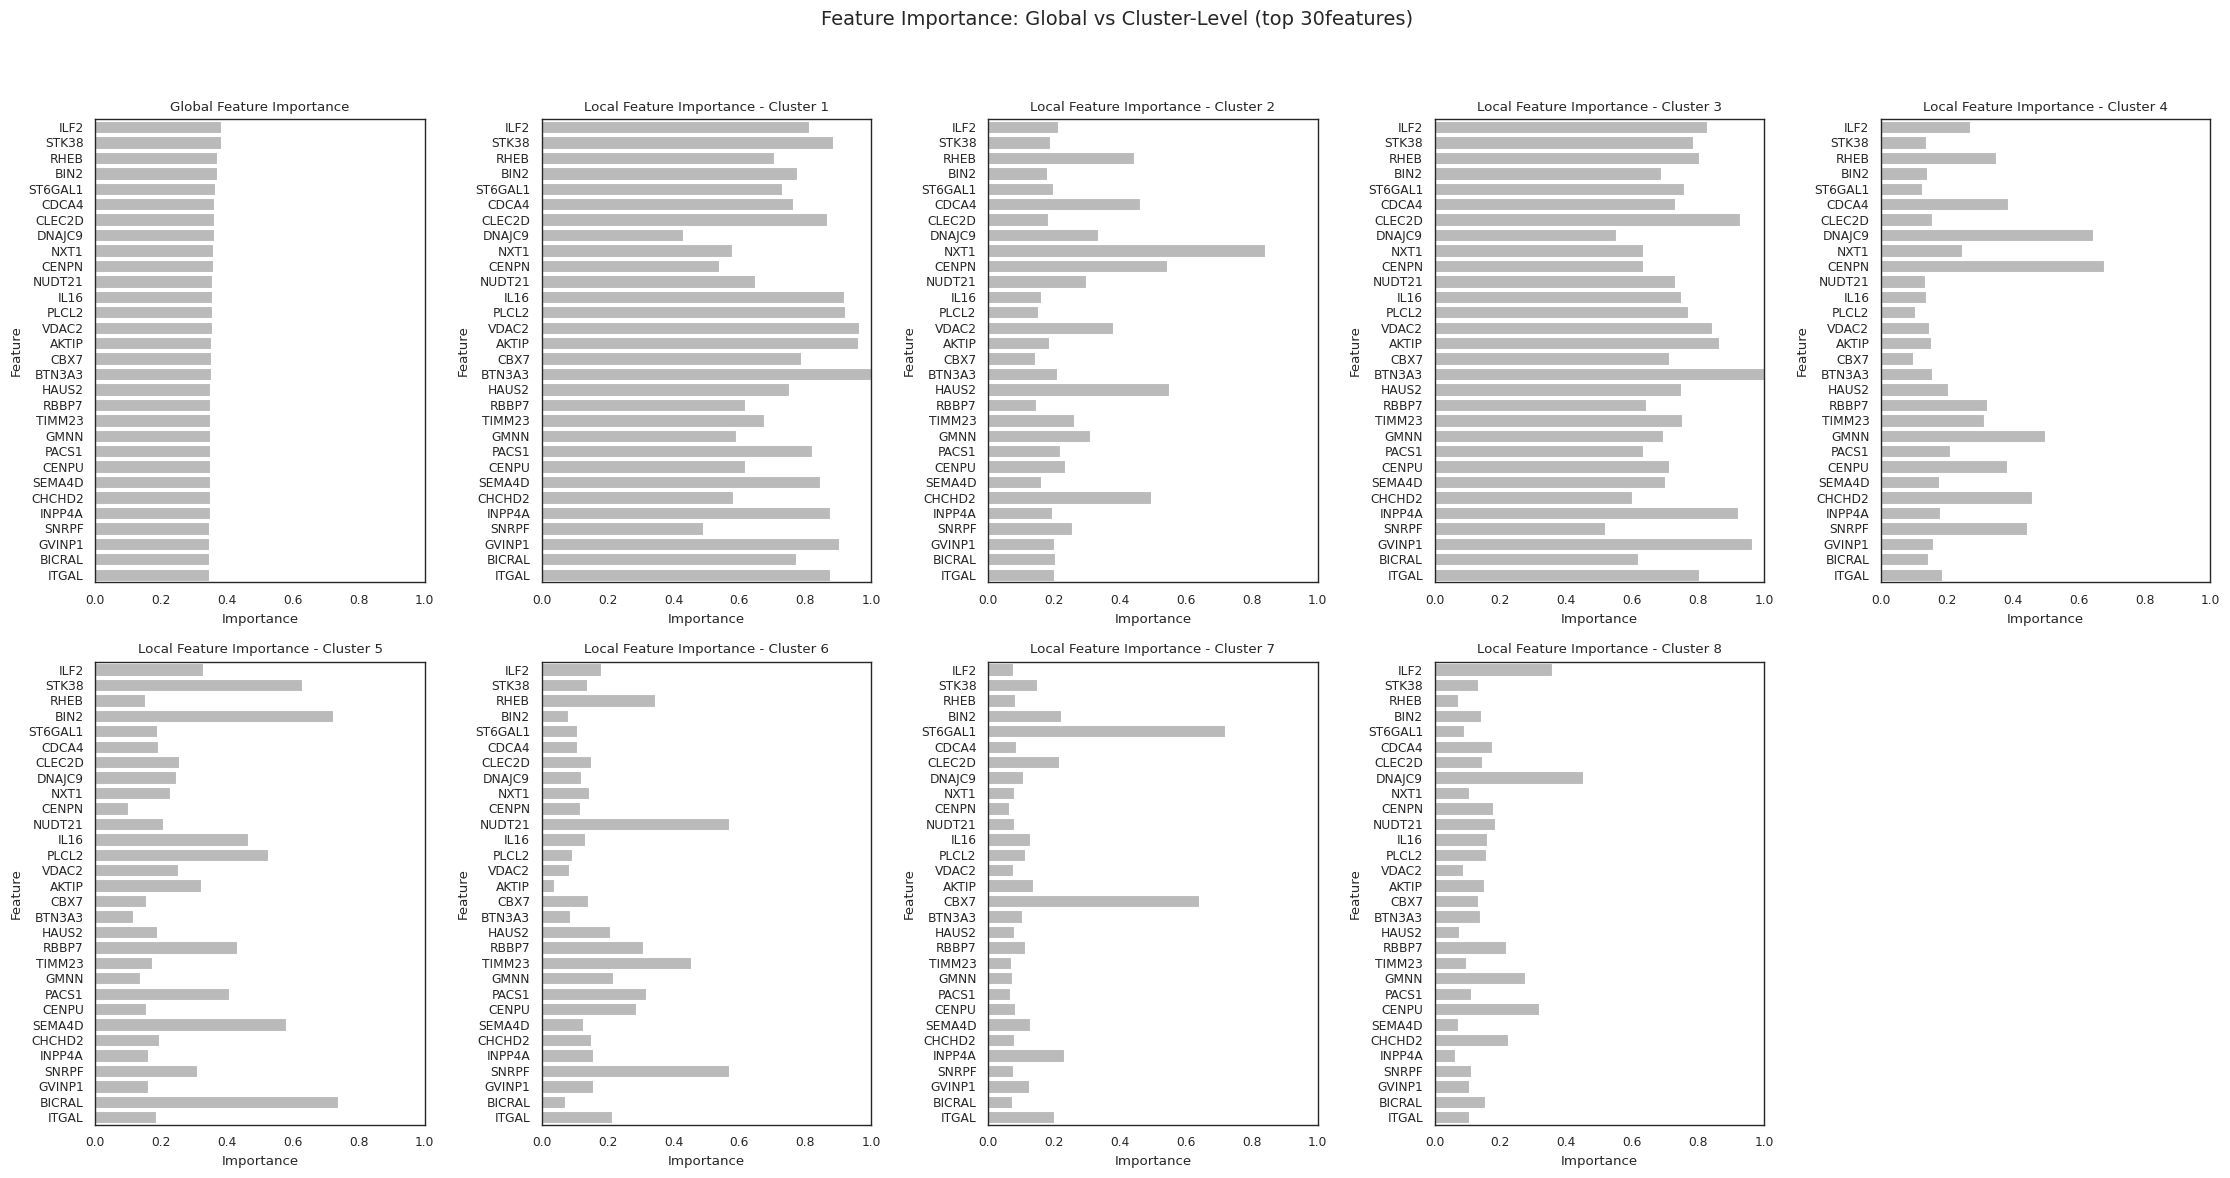

In [19]:
# plot top 30 globally important features
plot_forest_guided_feature_importance(
    feature_importance_local=feature_importance.feature_importance_local,
    feature_importance_global=feature_importance.feature_importance_global,
    top_n=top_n,
    num_cols=5,
    reorder=True,
)

Next, we visualize the decision path heatmap, which illustrates how gene expression patterns differ across clusters for the top-ranked features. Each cluster corresponds to a group of samples that follow similar decision paths within the Random Forest. The heatmap therefore provides insight into how distinct expression profiles map onto specific decision regions.

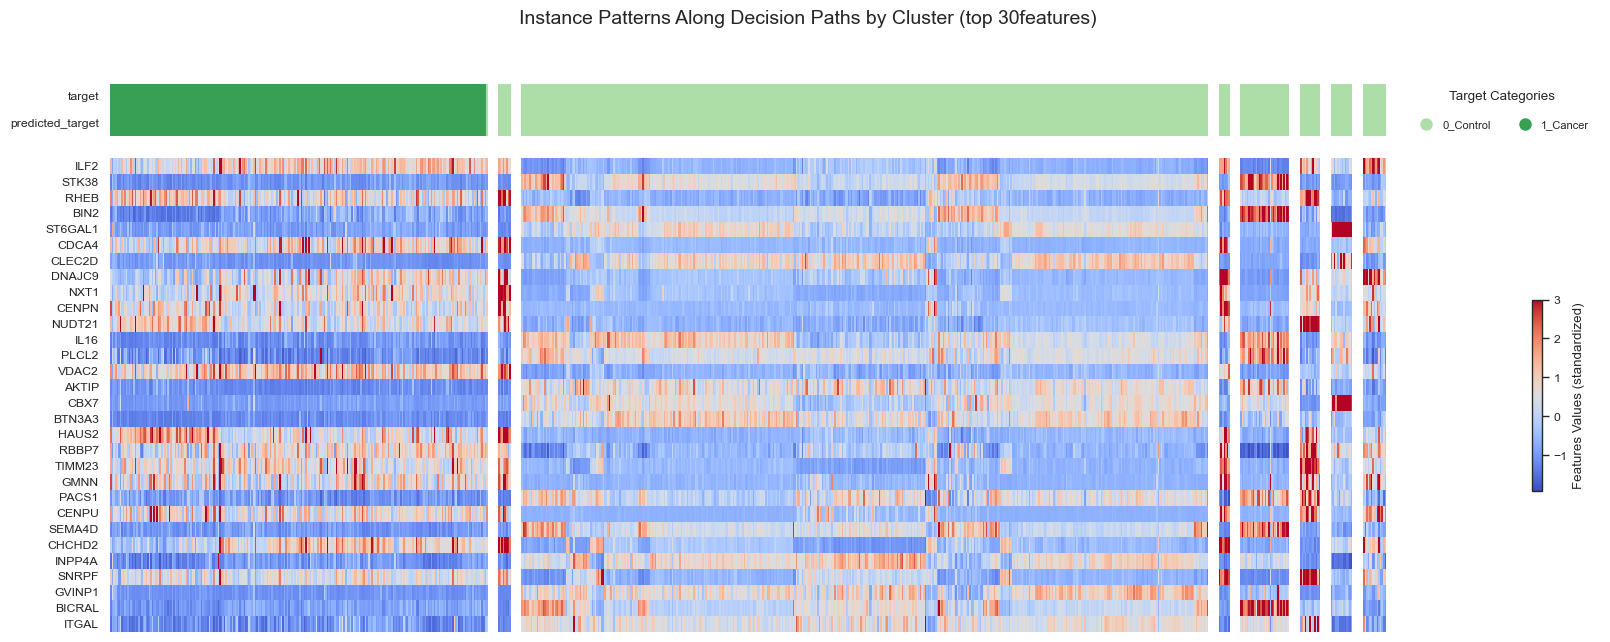

In [20]:
plot_forest_guided_decision_paths(
    data_clustering=feature_importance.data_clustering,
    feature_importance_global=feature_importance.feature_importance_global,
    feature_importance_local=feature_importance.feature_importance_local,
    model_type=fgc.model_type,
    top_n=top_n,
    draw_heatmap=True,
    draw_distributions=False,
    draw_dotplot=False,
)

The box plots allow us to examine the magnitude of expression differences between clusters and to assess the actual value ranges of the most influential features. By visualizing cluster-specific boxplots for the top genes, we gain deeper insight into how these features are distributed across the eight decision-path clusters and how strongly they differentiate specific subgroups.

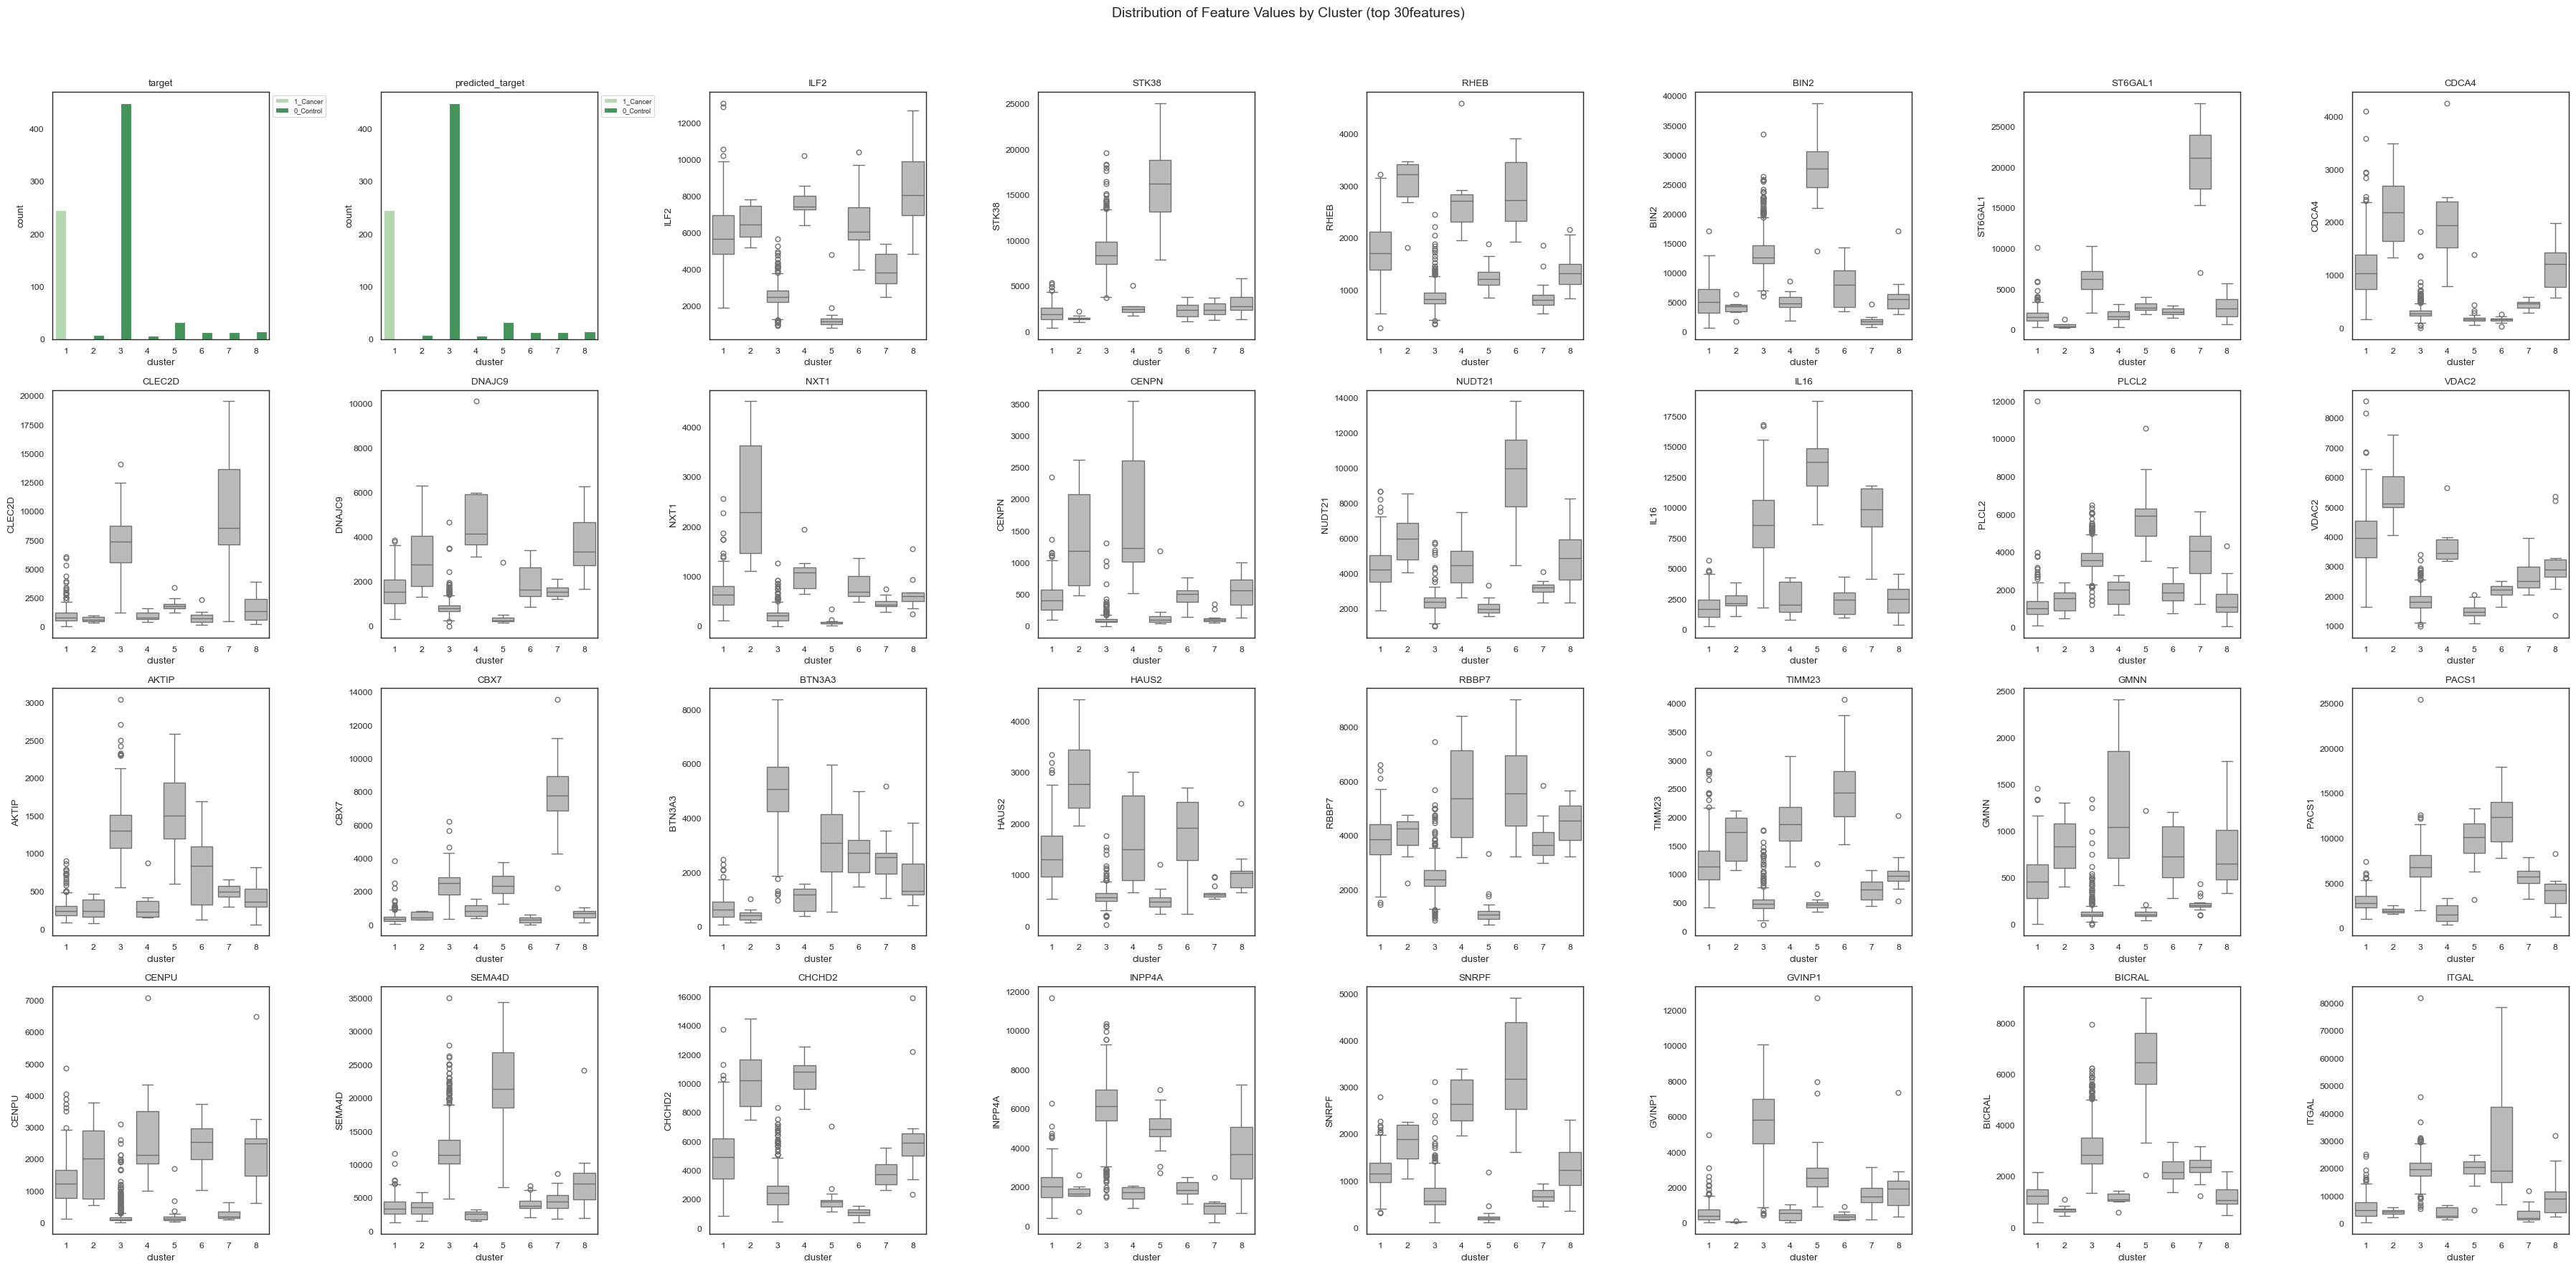

In [21]:
plot_forest_guided_decision_paths(
    data_clustering=feature_importance.data_clustering,
    feature_importance_global=feature_importance.feature_importance_global,
    feature_importance_local=feature_importance.feature_importance_local,
    model_type=fgc.model_type,
    top_n=top_n,
    num_cols=8,
    draw_heatmap=False,
    draw_distributions=True,
    draw_dotplot=False,
)

### Advanced Analysis with FGC

To better understand what distinguishes AML (Acute Myeloid Leukemia) samples from non-AML samples, and to assess potential confounding effects, we focus on the 30 most informative genes specific to the AML-enriched cluster identified by Forest-Guided Clustering.

We first extract the top 30 features based on cluster-specific (local) feature importance from the AML cluster. We then extend this feature set by incorporating relevant metadata variables, including tissue type (e.g., PBMC, bone marrow), study origin (e.g., GSE identifiers), and disease labels (e.g., ALL, CLL, healthy). This combined feature set allows us to evaluate both biological signals and potential technical or cohort-related influences. Feature importance is recomputed using this enriched feature space to assess the joint contribution of gene expression and metadata variables. 

Finally, we visualize the resulting decision paths to examine how clusters are structured and to identify whether technical or biological covariates may act as confounding factors. This analysis helps ensure that the observed separation of AML samples reflects meaningful biological patterns rather than study-specific or technical artifacts, strengthening confidence in the robustness of the model’s decision logic.

In [22]:
# select the top 30 locally important features for teh AML cluster
feature_importance_local = feature_importance.feature_importance_local
feature_importance_local.columns = [f"Cluster_{i+1}" for i in range(feature_importance_local.shape[1])]
feature_importance_local.sort_values(by="Cluster_1", ascending=False, inplace=True)

top_cancer_genes = list(feature_importance_local.index[:30])
selected_metadata = ["Tissue", "GSE", "Disease"]
selected_features = top_cancer_genes + selected_metadata

In [23]:
# calculate feature importance for the metadata
feature_importance_metadata = forest_guided_feature_importance(
    X=data_train[selected_features],
    y=data_train["Condition"], 
    cluster_labels=fgc.cluster_labels[fgc.best_k],
    feature_importance_distance_metric="jensenshannon",
)

100%|██████████| 33/33 [00:00<00:00, 187.57it/s]


The Forest-Guided Clustering analysis identifies eight distinct clusters, each representing groups of samples that follow similar decision paths within the trained Random Forest. Notably, Cluster 1 consists exclusively of AML samples, indicating that AML exhibits a highly distinct gene expression signature that the model captures consistently and robustly.

In contrast, non-AML samples are distributed across the remaining seven clusters (Clusters 2–8). These clusters show heterogeneous expression patterns, reflecting biological diversity among non-AML conditions and potentially the influence of technical or study-specific factors. This structured partitioning suggests that the model does not simply learn a single global AML versus non-AML boundary. Instead, it captures a more nuanced internal representation of the data.

Although the model was trained for binary classification, it implicitly organizes samples into meaningful subgroups based on shared decision logic. This layered structure highlights the capacity of tree-based models to encode complex biological patterns and may provide valuable insight for subtype exploration and for understanding model behavior in heterogeneous biomedical datasets.

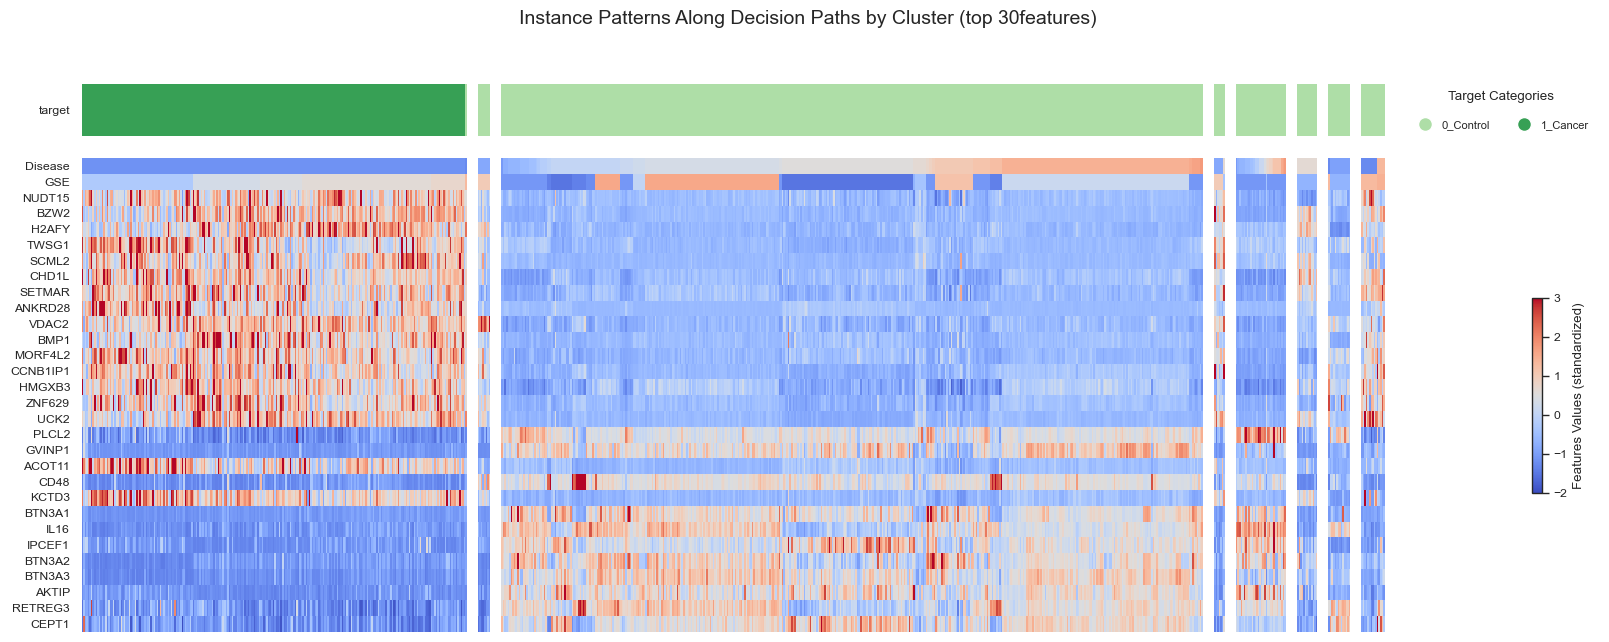

In [24]:
# plot decision path plot for the top cancer genes and metadata
plot_forest_guided_decision_paths(
    data_clustering=feature_importance_metadata.data_clustering,
    feature_importance_global=feature_importance_metadata.feature_importance_global,
    feature_importance_local=feature_importance_metadata.feature_importance_local,
    model_type=fgc.model_type,
    top_n=top_n,
    num_cols=8,
    draw_heatmap=True,
    draw_distributions=False,
    draw_dotplot=False,
)

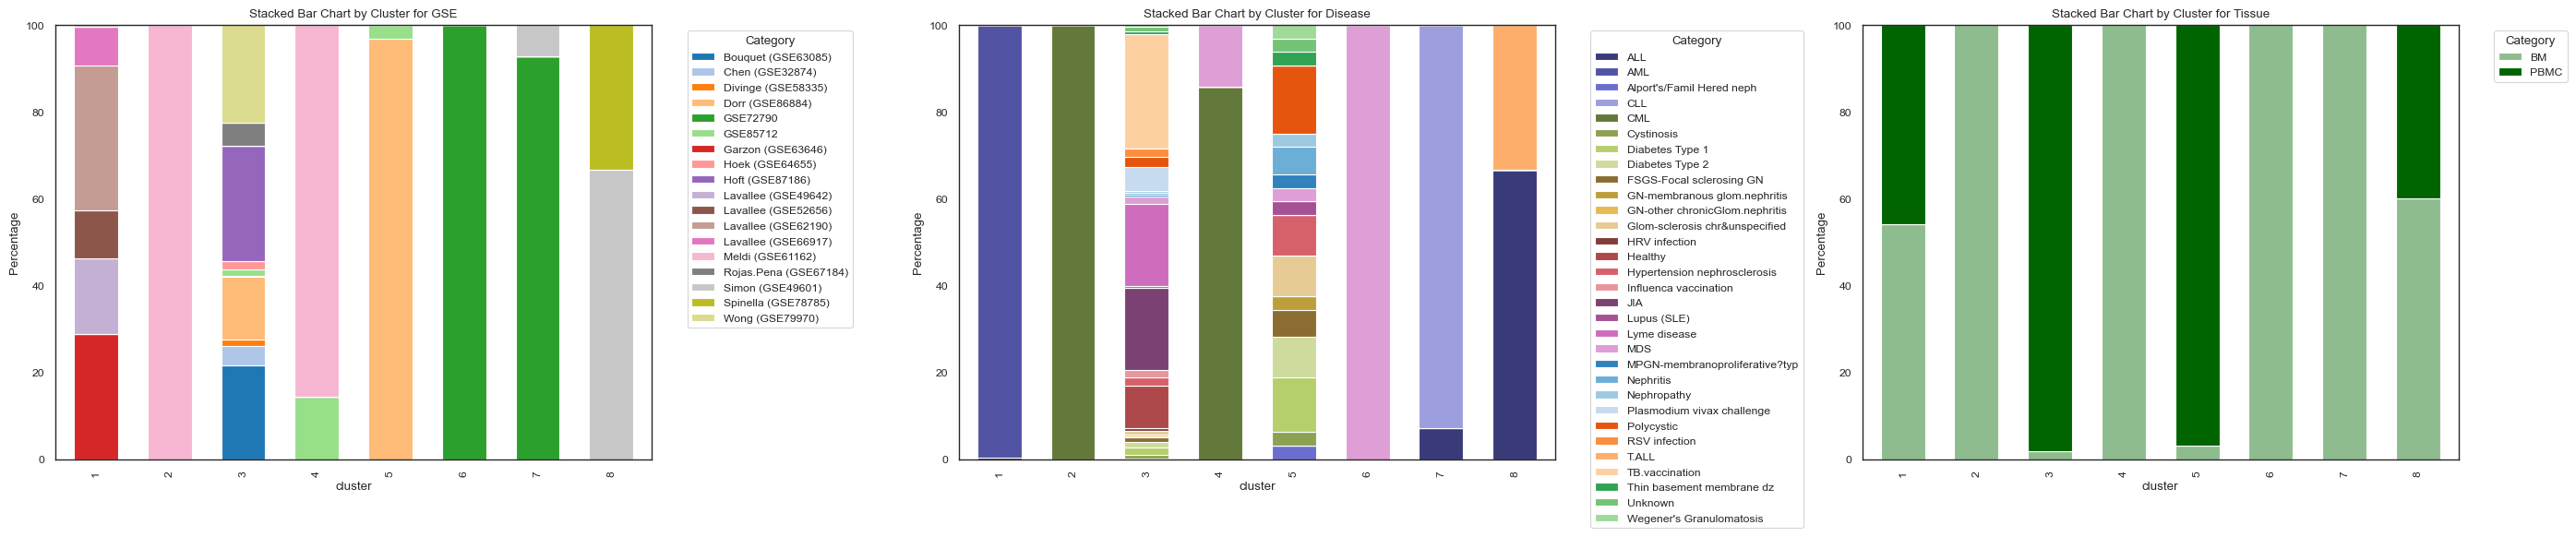

In [25]:
# visualize metadata as stacked bar plots
utils.plot_stacked_bar_chart(feature_importance_metadata, ["GSE", "Disease", "Tissue"])

100%|██████████| 100/100 [00:00<00:00, 456.19it/s]


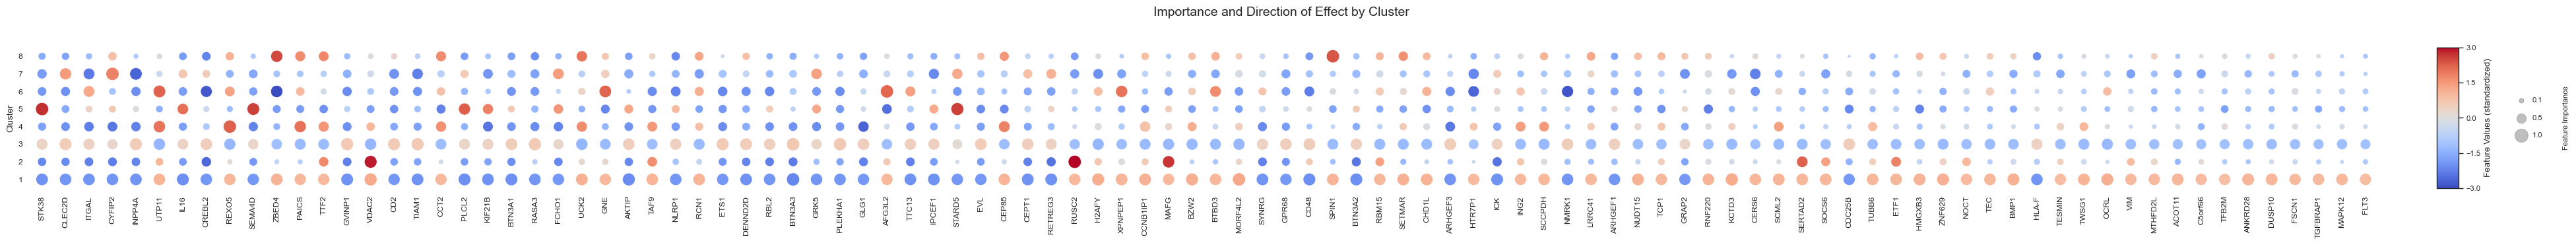

In [26]:
feature_importance_top_X = forest_guided_feature_importance(
    X=data_train[list(feature_importance_local.index[:100])],
    y=data_train["Condition"], 
    cluster_labels=fgc.cluster_labels[fgc.best_k],
    feature_importance_distance_metric="wasserstein",
)

plot_forest_guided_decision_paths(
    data_clustering=feature_importance_top_X.data_clustering,
    feature_importance_global=feature_importance_top_X.feature_importance_global,
    feature_importance_local=feature_importance_top_X.feature_importance_local,
    model_type=fgc.model_type,
    draw_heatmap=False,
    draw_distributions=False,
    draw_dotplot=True,
)

#### Comparison to unsupervised clustering

To assess the added value of the supervised Forest-Guided Clustering (FGC), we compare its results to an unsupervised k-medoids clustering approach. For consistency, we use the same number of clusters (k) determined by FGC and apply k-medoids directly on the standardized gene expression data using Euclidean distance. This allows us to evaluate whether incorporating model-derived information improves subgroup discovery and alignment with known biological labels.

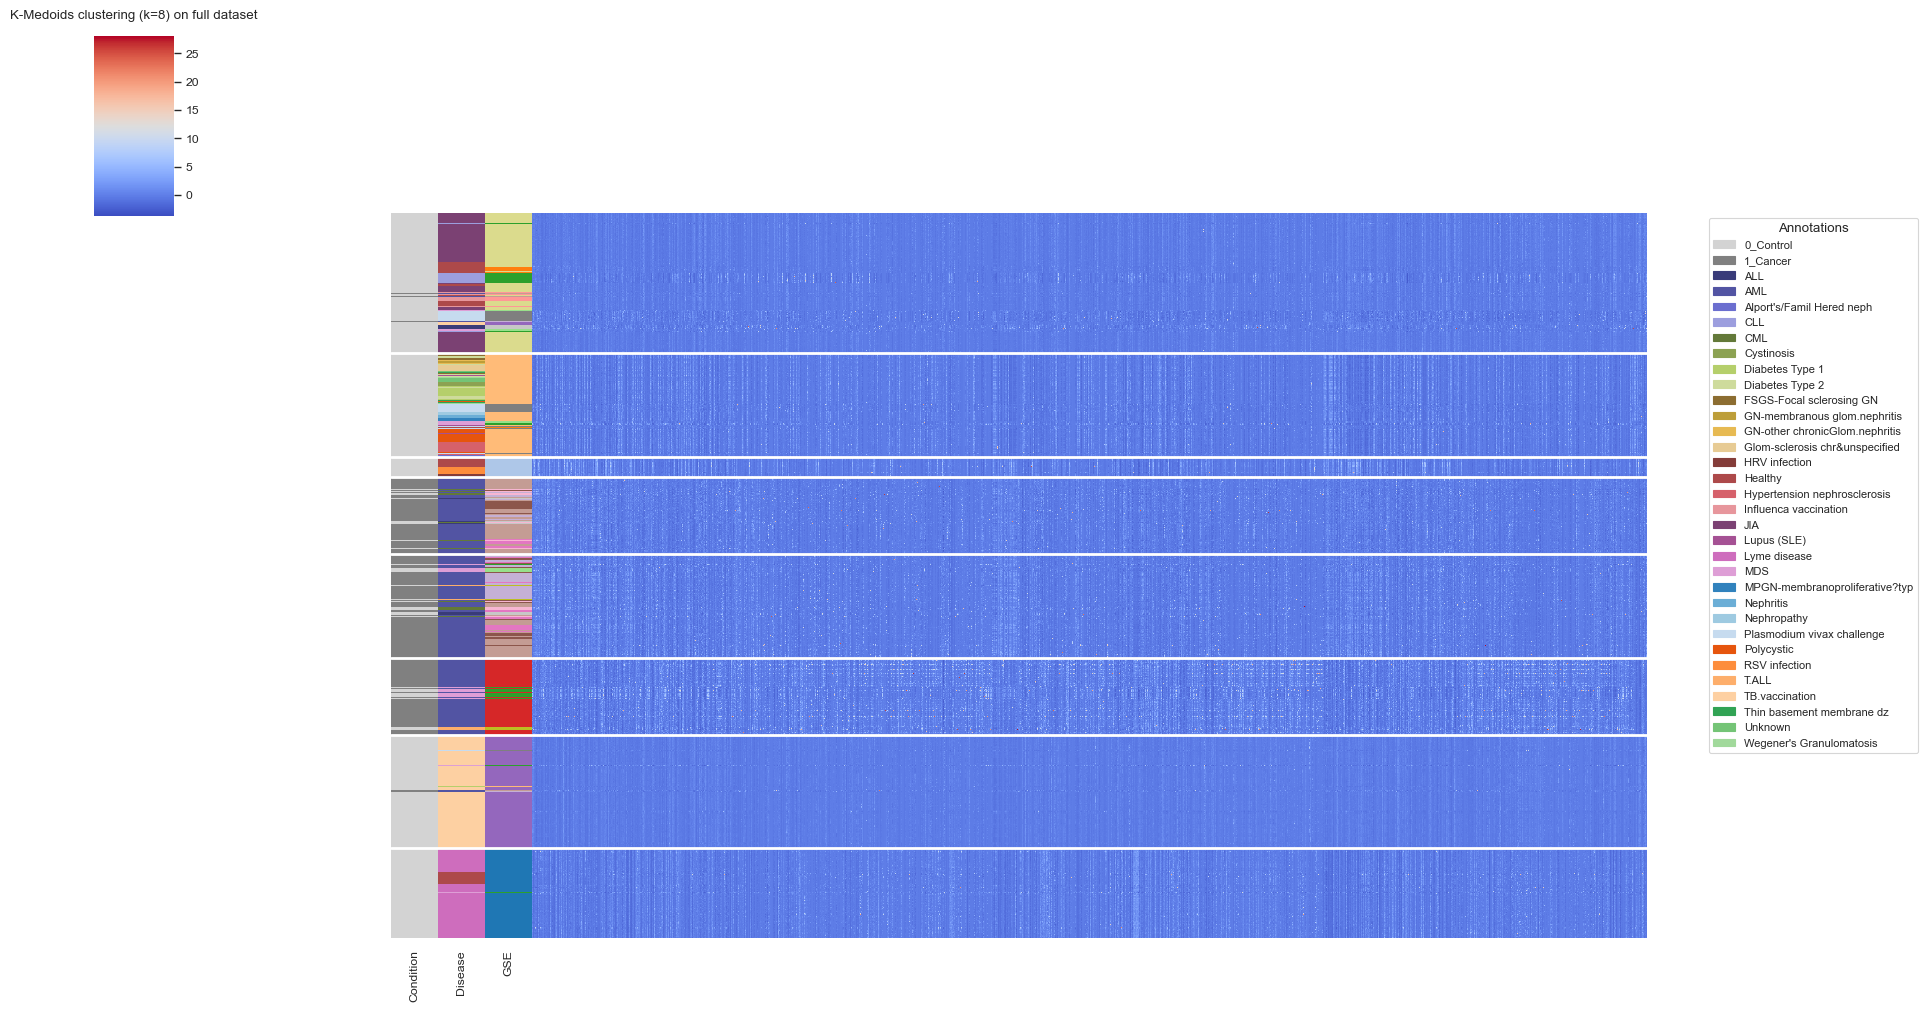

In [27]:
# comparse results with k-medoids clustering heatmap with k=8
dataset = utils.kmedoids_clustering_heatmap(data_train, k=8, name="case_study_1")

The k-medoids clustering applied to the expression data without supervision reveals key differences compared to the Forest-Guided Clustering (FGC) results.

From the heatmap above we observe that:
- AML samples, which were cleanly grouped into a single distinct cluster using FGC, are now scattered across three different clusters (clusters 2, 3, and 4). Each of these clusters also contains non-AML samples, including MDS, CML, and ALL cases, reducing the specificity of AML separation.
- Other leukemia types (e.g., CLL, ALL, CML, MDS) are also not clearly separated into dedicated clusters, suggesting that unsupervised clustering fails to isolate leukemia types effectively.
- Several clusters (e.g., clusters 0, 1, 6, and 7) are instead dominated by non-leukemic diseases such as JIA, TB-vaccination, or Lyme disease. These disease-specific groupings indicate that stronger expression patterns unrelated to leukemia are driving the clustering structure.

This result highlights an important limitation of purely unsupervised approaches: The most prominent sources of variation in high-dimensional expression data may not align with the clinical or biological question of interest. In contrast, the supervised FGC approach leverages model-driven proximity, enabling more targeted discovery of biologically or clinically relevant subgroups—such as the AML-specific cluster. This underscores the value of integrating predictive models into clustering for goal-oriented subgroup discovery.

<font color='green'>

#### Question 1: What do you observe when comparing the different XAI methods?

## Conclusion: Comparing XAI Methods

In this notebook, we applied and compared multiple explainability methods to interpret the trained Random Forest model for AML vs. non-AML prediction. Although all methods aim to quantify feature relevance, they differ substantially in their assumptions, interpretability, sensitivity to feature dependence, and the type of information they provide.


### Permutation Feature Importance 

The permutation feature importance (PFI) results show near-zero importance values for most genes. Permuting individual features does not substantially decrease model performance. In high-dimensional RNA-seq data, many genes are strongly correlated and share overlapping biological signal. Because PFI permutes one feature at a time, correlated genes can compensate for the permuted feature, resulting in weak or diluted importance estimates. Thus, PFI tends to underestimate feature relevance in highly correlated settings.

PFI is model-agnostic and intuitive, but in redundant feature spaces it provides limited insight into how predictive signal is distributed across correlated gene groups.

### Random Forest Feature Importance

The built-in Random Forest feature importance (RFFI) produces a clear ranking of influential genes. However, RFFI does not explicitly account for feature correlation. When predictors are correlated, importance may be distributed across them depending on how often they are selected in tree splits. Additionally, RFFI can be biased toward features with higher variance or more splitting opportunities.


### SHAP

SHAP provides both global and local explanations of the Random Forest model. The global SHAP ranking shows substantial agreement with the RFFI, increasing confidence in the stability of the top-ranked genes. At the same time, SHAP decomposes each individual prediction into additive feature contributions, allowing us to quantify how much each gene pushes a prediction toward AML or non-AML.

The SHAP summary plots reveal the direction of effects (whether high or low expression increases AML probability), the variability of contributions across samples, and class-specific impact patterns. In contrast to PFI, SHAP distributes interaction effects across correlated features, making it more robust in redundant, high-dimensional settings. However, it still relies on assumptions about feature independence when estimating conditional expectations, so interpretations must remain cautious in strongly correlated feature spaces. Overall, SHAP provides richer insight than purely global ranking methods by linking global importance with local, directional effects.

### Forest-Guided Clustering

Forest-Guided Clustering (FGC) moves beyond individual feature attribution and instead examines the structure of the model’s decision process. By grouping samples that follow similar decision paths, FGC reveals that the Random Forest does not rely on a single global AML vs. non-AML rule, but instead partitions the data into distinct decision regions with partially different gene signatures.

Overlaying metadata onto clusters adds further interpretability. For example, clusters dominated by a single study may indicate batch effects, whereas the absence of tissue-driven clustering suggests that the model is not primarily separating bone marrow from PBMC samples. The presence of distinct clusters for different leukemia subtypes shows that the model captures biological structure beyond the binary label, implicitly distinguishing subtypes without being explicitly trained to do so.

FGC therefore provides subgroup-level interpretability and helps identify hidden structure and potential confounding factors. Because it leverages the internal tree structure rather than perturbing individual features, it is less sensitive to feature correlation and particularly informative in high-dimensional transcriptomic data.

### Final Remarks

Feature correlation plays a central role in interpreting explainability results in high-dimensional transcriptomic data. Redundant gene expression patterns weaken perturbation-based methods and distribute importance across correlated predictors.

No single XAI method provides a complete understanding of model behavior:

- **PFI** highlights limitations in correlated feature spaces.
- **RFFI** offers fast global ranking but may be biased.
- **SHAP** provides stable global and local explanations.
- **FGC** reveals structured heterogeneity, subgroup logic, and potential confounding effects.

Together, these complementary perspectives show that the Random Forest model captures not only AML vs. non-AML separation but also richer biological structure, including implicit discrimination among leukemia subtypes and study-level variation. Combining multiple XAI approaches provides a more comprehensive and reliable understanding of model behavior in complex, high-dimensional biomedical settings.
